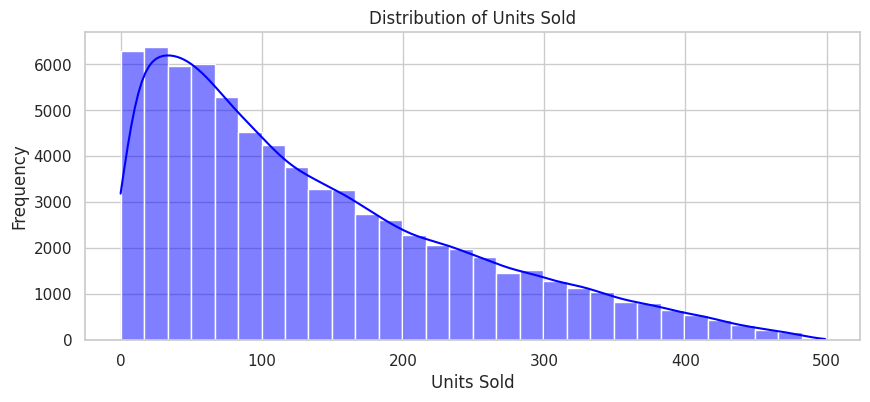

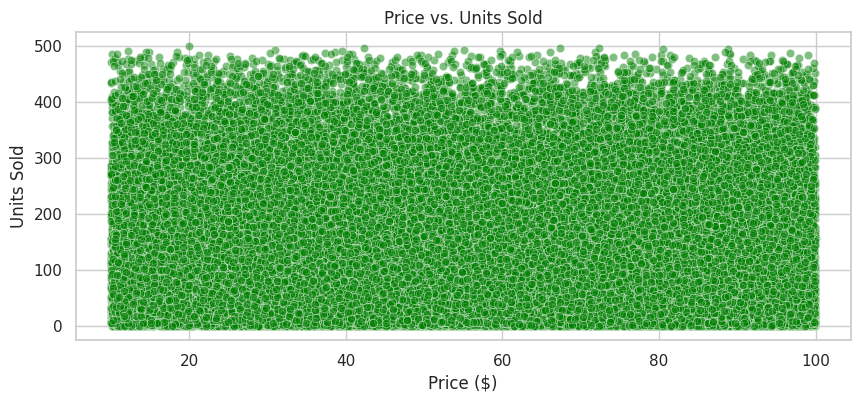

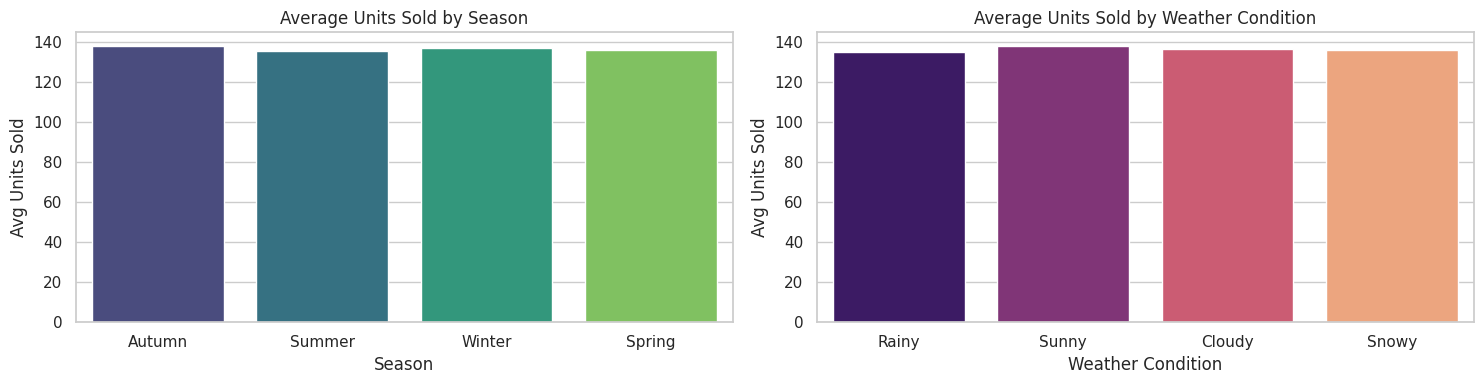

Training model... please wait.
Model trained successfully!

Mean Squared Error (MSE): 8097.45
R-squared (R2) Score: 0.3161

--- Retail Inventory Forecaster ---
Adjust the inputs to forecast unit sales!


FloatText(value=50.0, description='Price ($):')

IntText(value=10, description='Discount (%):')

Dropdown(description='Holiday:', options=(('No', 0), ('Yes', 1)), value=0)

Dropdown(description='Weather:', options=('Rainy', 'Sunny', 'Cloudy', 'Snowy'), value='Rainy')

Dropdown(description='Season:', options=('Autumn', 'Summer', 'Winter', 'Spring'), value='Autumn')

Button(button_style='success', description='Predict Sales', style=ButtonStyle())

Output()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import ipywidgets as widgets
from IPython.display import display, clear_output
import warnings
warnings.filterwarnings('ignore') # Hides unnecessary background warnings

# ---------------------------------------------------------
# 1. LOAD AND PREPARE DATA
# ---------------------------------------------------------
# Load the dataset
df = pd.read_csv('retail_store_inventory.csv')

# Convert text columns into numbers (One-Hot Encoding)
categorical_columns = ['Category', 'Region', 'Weather Condition', 'Seasonality']
df_encoded = pd.get_dummies(df, columns=categorical_columns, drop_first=True)

# Drop columns that cause data leakage or aren't useful for prediction
df_model = df_encoded.drop(columns=['Date', 'Store ID', 'Product ID', 'Demand Forecast', 'Units Ordered'])

# ---------------------------------------------------------
# 2. DATA VISUALIZATIONS (Matches Task 1 Proposal)
# ---------------------------------------------------------
sns.set_theme(style="whitegrid")

# Visualization 1: Histogram of Units Sold
plt.figure(figsize=(10, 4))
sns.histplot(df['Units Sold'], bins=30, kde=True, color='blue')
plt.title('Distribution of Units Sold')
plt.xlabel('Units Sold')
plt.ylabel('Frequency')
plt.show()

# Visualization 2: Scatter plot of Price vs. Units Sold
plt.figure(figsize=(10, 4))
sns.scatterplot(x='Price', y='Units Sold', data=df, alpha=0.5, color='green')
plt.title('Price vs. Units Sold')
plt.xlabel('Price ($)')
plt.ylabel('Units Sold')
plt.show()

# Visualization 3: Bar charts for Seasonality and Weather
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

sns.barplot(x='Seasonality', y='Units Sold', data=df, ax=axes[0], palette='viridis', errorbar=None)
axes[0].set_title('Average Units Sold by Season')
axes[0].set_xlabel('Season')
axes[0].set_ylabel('Avg Units Sold')

sns.barplot(x='Weather Condition', y='Units Sold', data=df, ax=axes[1], palette='magma', errorbar=None)
axes[1].set_title('Average Units Sold by Weather Condition')
axes[1].set_xlabel('Weather Condition')
axes[1].set_ylabel('Avg Units Sold')

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 3. MACHINE LEARNING MODEL
# ---------------------------------------------------------
# Define our Features (X) and our Target (y)
X = df_model.drop('Units Sold', axis=1)
y = df_model['Units Sold']

# Split the data (80% for training, 20% for testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build and train the Random Forest model
print("Training model... please wait.")
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
print("Model trained successfully!\n")

# Evaluate how well the model did
y_pred = rf_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2) Score: {r2:.4f}\n")

# ---------------------------------------------------------
# 4. INTERACTIVE USER INTERFACE
# ---------------------------------------------------------
print("--- Retail Inventory Forecaster ---")
print("Adjust the inputs to forecast unit sales!")

# Extract unique values from the dataframe for the dropdowns
weather_options = df['Weather Condition'].dropna().unique().tolist()
season_options = df['Seasonality'].dropna().unique().tolist()

# Create interactive input widgets
price_input = widgets.FloatText(value=50.0, description='Price ($):')
discount_input = widgets.IntText(value=10, description='Discount (%):')
holiday_input = widgets.Dropdown(options=[('No', 0), ('Yes', 1)], value=0, description='Holiday:')
weather_input = widgets.Dropdown(options=weather_options, description='Weather:')
season_input = widgets.Dropdown(options=season_options, description='Season:')

predict_button = widgets.Button(description="Predict Sales", button_style='success')
output = widgets.Output()

def make_prediction(b):
    with output:
        clear_output()
        # 1. Borrow a realistic baseline row from our test data
        user_data = X_test.iloc[[0]].copy()

        # 2. Update the numerical inputs from the widgets
        user_data['Price'] = price_input.value
        user_data['Discount'] = discount_input.value
        if 'Holiday/Promotion' in user_data.columns:
            user_data['Holiday/Promotion'] = holiday_input.value

        # 3. Reset ALL Weather and Seasonality dummy columns to 0
        for col in user_data.columns:
            if 'Weather Condition_' in col or 'Seasonality_' in col:
                user_data[col] = 0

        # 4. Set the specific Weather and Seasonality chosen by the user to 1
        weather_col = f"Weather Condition_{weather_input.value}"
        season_col = f"Seasonality_{season_input.value}"

        if weather_col in user_data.columns:
            user_data[weather_col] = 1
        if season_col in user_data.columns:
            user_data[season_col] = 1

        # 5. Ask the Random Forest model to predict
        prediction = rf_model.predict(user_data)[0]

        print(f"\n📈 Predicted Units Sold: {prediction:.0f} units")

predict_button.on_click(make_prediction)

# Display the user interface
display(price_input, discount_input, holiday_input, weather_input, season_input, predict_button, output)